# Simulazione prova d'esame

## Quesito numero 1

Si consideri il data set sintetico presente nel file data.csv costituito da 3000 punti
con 15 feature numeriche cadauno e una label binaria di classe con valori
appartenenti a {0, 1}.

1. Caricare il dataset, estrarre randomicamente un test set pari al 5% dei dati,
mantenendo il restante 95% come training set vero e proprio. Calcolare e
stampare la matrice di correlazione tra le feature e trasformare gli eventuali
dati multicollineari con una opportuna combinazione lineare. Infine
selezionare le feature rilevanti tramite il Fisher score.

In [ ]:
import numpy as np
import pandas as pd


# Carico il dataset in memoria

df = pd.read_csv('data.csv')

print(df.shape)
print(df.head())
print(df.info())


In [2]:

# La label (ovvero la feature che il modello deve imparare a prevedere) è class
# Estraggo features e label

X = df.drop(columns=['class'])
y = df['class']

print("Shape di X:", X.shape)
print("Shape di y:", y.shape)
print("Tipo di X:", type(X))
print("Tipo di y:", type(y))

Shape di X: (3000, 15)
Shape di y: (3000,)
Tipo di X: <class 'pandas.core.frame.DataFrame'>
Tipo di y: <class 'pandas.core.series.Series'>


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.05,
    random_state=42,
    #stratify forza lo split a conservare le proporzioni delle classi in entrambi i sottoinsiemi 
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)
print("\nDistribuzione classi nel training:")
print(y_train.value_counts(normalize=True))
print("\nDistribuzione classi nel test:")
print(y_test.value_counts(normalize=True))

Shape X_train: (2850, 15)
Shape X_test: (150, 15)
Shape y_train: (2850,)
Shape y_test: (150,)

Distribuzione classi nel training:
class
1    0.501053
0    0.498947
Name: proportion, dtype: float64

Distribuzione classi nel test:
class
0    0.5
1    0.5
Name: proportion, dtype: float64


La **matrice di correlazione** è una tabella quadrata 15x15 (una riga e una colonna per ogni feature) dove la cella (i, j) contiene il coefficiente di correlazione di Pearson tra feature_i e feature_j.

Il *coefficiente di Pearson* è un numero tra -1 e +1:

+1 significa correlazione lineare perfetta positiva: quando una feature cresce, l'altra cresce proporzionalmente.
-1 significa correlazione lineare perfetta negativa: quando una cresce, l'altra decresce proporzionalmente.
0 significa nessuna relazione lineare (attenzione: potrebbe esserci una relazione non lineare e Pearson non se ne accorgerebbe).

La matrice di correlazione va calcolata solo sul **training set**

            feature_0  feature_1  feature_2  ...  feature_12  feature_13  feature_14
feature_0    1.000000  -0.012855   0.014164  ...    0.017301    0.003137    0.023884
feature_1   -0.012855   1.000000   0.012463  ...   -0.007345    0.016644    0.003639
feature_2    0.014164   0.012463   1.000000  ...   -0.010595   -0.021873   -0.002773
feature_3   -0.006998   0.029422  -0.007890  ...    0.007436    0.197928    0.016405
feature_4    0.013279  -0.002651  -0.016351  ...    0.020071    0.834696   -0.015885
feature_5    0.004592  -0.003404   0.006605  ...   -0.009187   -0.014351    0.001197
feature_6   -0.026430   0.020757  -0.007223  ...    0.013616    0.365858   -0.024174
feature_7    0.022959   0.015496  -0.022246  ...    0.026500    0.680366   -0.004964
feature_8    0.005459   0.006648   0.008433  ...   -0.009013   -0.588587    0.022084
feature_9   -0.005515   0.031613  -0.005712  ...   -0.001765   -0.005948    0.023488
feature_10  -0.033864   0.006309   0.019941  ...    0.006966    0

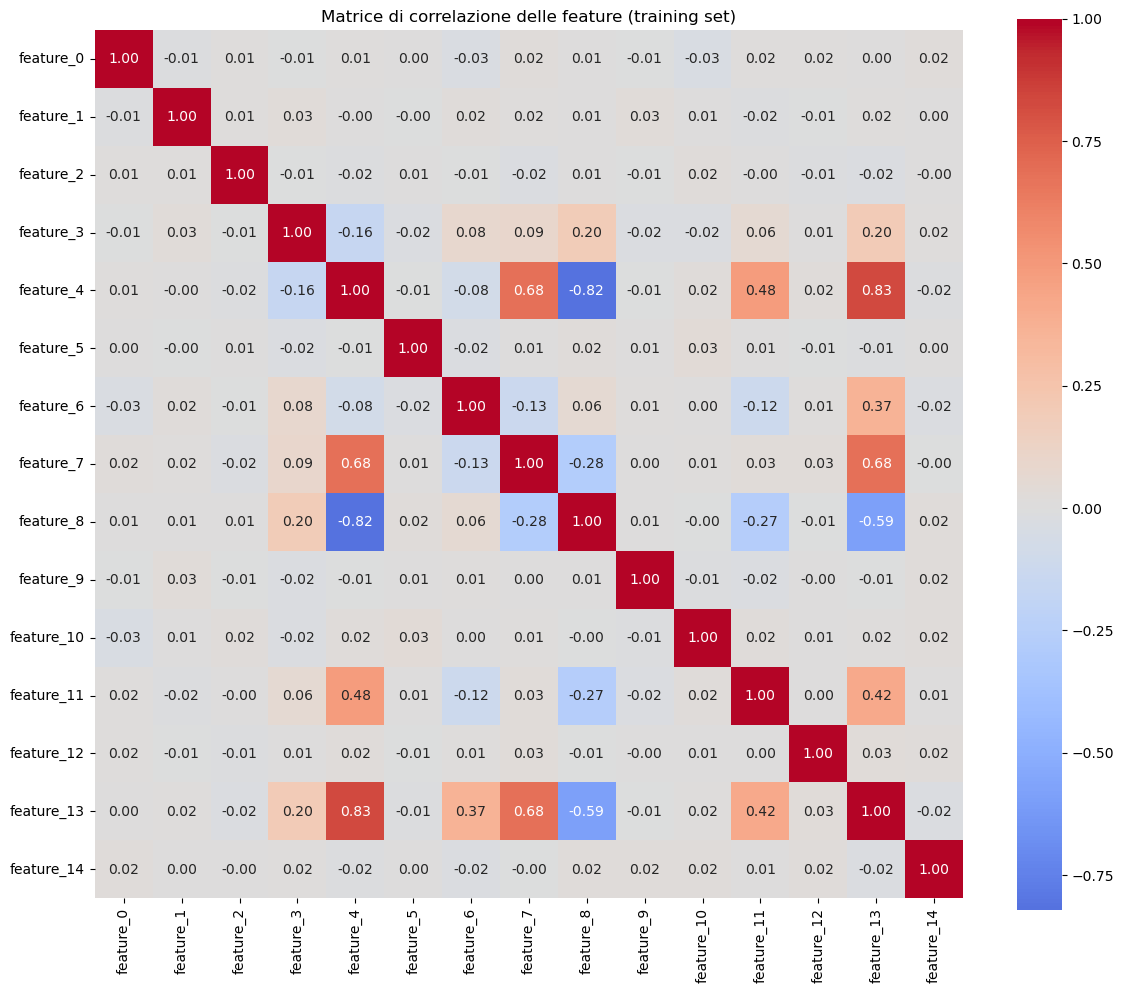

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = X_train.corr()
print(corr_matrix)

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,
            annot=True, # annota i valori
            fmt='.2f', # due cifre decimali
            cmap='coolwarm',
            center=0, # centra la palette sullo zero
            square=True # celle quadrate
)
plt.title('Matrice di correlazione delle feature (training set)')
plt.tight_layout()
plt.show()